#  Modèles simplifiés du climat

Dans ce TP, vous allez utiliser différents modèles physiques qui permettent de déterminer la température globale de la terre ou de prédire son évolution:  
- Le premier exercice permet d'établir cette température avec la **loi de Stefan-Boltzmann** vue en cours et en prenant en compte ou non l'**albedo**. Pour rappel l'albedo est le pouvoir réfléchissant d'un corps: 1 pour un miroir parfait et 0 pour le corps noir.  
- Le deuxième exercice pousse un peu plus loin en considérant un **albedo qui varie en fonction de la température**. Il s'agit alors de déterminer des températures qui réalisent un **équilibre** entre la puissance reçue par la terre et celle qu'elle rayonne. On terminera par une simulation numérique qui donne l'**évolution de la température en fonction du temps** et en regardant l'**influence des gaz à effet de serre**.

##  Exercice 1 - Calcul de la Temperature de la Terre sans tenir compte de l'Atmosphère

### 1 - Calcul de la Puissance Solaire

Considérons que le soleil est un corps noir parfait.

a) Calculez la puissance émise par le soleil $P_{sol}$ en une seconde, en utilisant la loi de Stefan-Boltzmann :
    
$$
P_{sol} = \sigma . A . T_{sol}^4
$$

où :

-   $\sigma$ est la constante de Stefan-Boltzmann ($5.67 \times 10^{-8} \, \text{W/m}^2\text{K}^4$),
-   $A$ est la surface du Soleil, son rayon est de 695 700 km
-   $T_{sol}$ est la température effective moyenne de la surface du Soleil (5772 K)


In [139]:
import math

sigma = 5.67e-8
R = 695700e3
A = 4 * math.pi * R**2
T_sol = 5772

P_sol = sigma * A * T_sol**4 

print(P_sol, 'W')

3.8277381380933445e+26 W


b) Comparez votre résultat à la valeur exacte que vous trouvez sur internet. L'hypothèse de considérer que le soleil se rapproche d'un corps noir parfait est-elle réaliste ? 

Selon ce lien : https://planet-terre.ens-lyon.fr/ressource/illustration-effet-de-serre.xml#:~:text=On%20d%C3%A9finit%20la%20luminosit%C3%A9%20du,(150%20millions%20de%20kilom%C3%A8tres), la puissance du soleil est évaluée à Ls = 3,85.10e+26 W. L'écart entre mon résultat et la valeurs de Ls est de 0.03 W. Il est négligeable.

Un corps noir parfait est un objet idéal qui absorbe tout le rayonnement incident et émet un rayonnement thermique maximal.  L'hypothèse consistant à assimiler le Soleil à un coprs noir parfait est donc raisonnable dans ce cadre. Cependant, le soleil n'est pas un corps noir idéal, son spectre s'en rapproche seulement.

### 2 - Calcul de la Constante Solaire

La constante solaire $F_{sol}$ est la quantité d'énergie solaire reçue par unité de surface au sommet de l'atmosphère terrestre (au niveau de l'orbite terrestre). La diffusion isotrope de la puissance solaire fait que l'on doit diviser celle-ci par la surface de la sphère dont le rayon est la distance Soleil-Terre.

$$
F_{sol} = \frac{P_{sol}}{A_{sphere}}
$$

où:

-   $P_{sol}$ est la puissance totale émise par le Soleil,
-   $A_{sphere}$ est l'aire de la sphère ayant pour centre le Soleil et pour rayon la distance moyenne de la Terre au Soleil (149 597 870.7 km)

En quelle unité est-elle exprimée ? Comparez votre résultat à la valeur exacte que vous trouvez sur internet.

#### Analyse dimensionnelle de la puissance émise par le soleil :

On réalise une analyse dimensionelle pour déterminer l'unité de F_sol.
 
$$[\sigma] = \text{W}\cdot\text{m}^{-2}\cdot\text{K}^{-4}$$

$$[A] = \text{m}^2$$

$$[T_{sol}] = \text{K}$$

donc la puissance est : 

$$
[P_{sol}] = [\sigma \cdot A \cdot T_{sol}^4] = \text{W}\cdot\text{m}^{-2}\cdot\text{K}^{-4} \cdot \text{m}^2 \cdot \text{K}^{4}
$$

$$
[P_{sol}] = \text{W}
$$
et l'aire de la sphère est :
$$[A_{sphere}] = \text{m}^2$$

donc la constante solaire : 
$$
[F_{sol}] = [P_{sol}] \cdot [A_{sphere}]^{-1} = \text{W} \cdot \text{m}^{-2}  
$$

La constante solaire esr exprimée en $\text{W} \cdot \text{m}^{-2}$. 



### 3. Calcul de la Puissance Totale reçue par la Terre

Même si la Terre est une sphère, la quantité de puissance solaire reçue est captée par un disque de rayon égal au rayon de la Terre, car seul
l'hémisphère faisant face au Soleil reçoit les rayons du soleil. Ceux-ci étant parallèles au plan de l'écliptique.

Calculez cette puissance, selon la formule suivante :

$$
P_{terre} = F_{sol} . A_{réception, terre}
$$

où:

- $A_{réception, terre}$ est l'aire du disque de reception des rayons du soleil. Le rayon de la Terre est d'environ $6371 km$.


In [140]:
#Le rayon de la terre
R_terre = 6371e3

#Distance Soleil-Terre en mètres
D = 149.5978707e9

#Surface de la sphère autour du Soleil jusqu'à la Terre
A_sphere = 4 * np.pi * D**2

#Flux solaire reçu à la distance de la Terre
F_sol = P_sol/ A_sphere

#Aire du disque qui intercepte les rayons du Soleil
A_reception_terre = np.pi * R_terre**2

#Puissance totale reçu par la Terre
P_terre = F_sol * A_reception_terre

print("La puissance totale reçue par la Terre est", P_terre, "W")

La puissance totale reçue par la Terre est 1.735587901456514e+17 W


### 4. Calcul de la Température de la Terre

Nous supposons ici que :

- la Terre est un corps noir parfait,
- celle-ci n'a pas d'atmosphère.

a) Calculez la température de la Terre **en Kelvin** en utilisant la loi de Stefan-Boltzmann. La puissance émise par la terre est diffusée à travers toute sa surface (qui est celle d'une sphère).

$$
P_{terre} = \sigma . A_{émission, terre} . T_{terre}^4
$$


In [141]:
import numpy as np

A_emission_terre = 4 * np.pi * R_terre ** 2

#Température de la Terre en Kelvin 
T_terre = (P_terre / (sigma * A_emission_terre ) )  ** (1/4)

print("La température de la Terre en Kelvin est", T_terre, "K")

La température de la Terre en Kelvin est 278.32974406155284 K


b) En quelle unité est-elle exprimée. Convertissez dans une unité plus compréhensible par un non-expert. Cherchez sur internet ou dans le cours la température moyenne mesurée en 1870, 1920, 1970 et 2020. Comparez ces valeurs à votre résultat. Que pouvez-vous en conclure ? 

In [142]:
#Conversion de la température de Kelvin en degrés Celsius
T_celsius = T_terre - 273.15

print("La température de la Terre est", T_celsius, "°C")

La température de la Terre est 5.179744061552867 °C


Dans le diaporama CM2, on trouve des valeurs de température moyenne mesurées en 1870, 1920, 1970 et 2020. Ces valeurs sont : 1850 : 13.7 °C ; 1900 : 13.7 °C ; 1920 : 13.72 °C ; 1970 : 13.92 °C ; 2020 : 14.76 °C.

On constante que la température obtenue est nettement plus faible que les températures réellement observées. Cela s'explique par le fait que Le modèle suppose que la Terre est un corps noir parfait sans atmosphère et ne prend pas en compte beaucoup de paramètres. En réaliré, l'atmosphère contient des gazs à effet de serre qui retiennent une partie du rayonnement infrarouge émis par la Terre et réchauffent sa surface.

### 5. Prise en compte de l'Albédo

La Terre réfléchit une partie du rayonnement électromagnétique vers l'espace. La puissance reçue du soleil est donc pondérée par $(1 - a)$ où $a$ est l'albédo.

a) Cherchez sur internet la valeur moyenne de l'albédo de la Terre. Calculez la puissance solaire reçue en tenant compte de celle-ci.



In [143]:
#Albédo moyen de la Terre (selon https://www.universalis.fr/media/albedo-moyen-de-differents-milieux-a-la-surface-de-la-terre-de240532/)
albedo = 0.30

#Puissance réellement absorbée par la Terre
P_absorbee = P_terre * (1 - albedo)

print("La puissance absorbée par la Terre est", P_absorbee, "W")

La puissance absorbée par la Terre est 1.2149115310195597e+17 W


b) Recherchez sur internet la puissance de la plus grande centrale electrique mondiale (au passage, quelle énergie y est utilisée pour produire l'électricité ? Est-ce une énergie verte ?). Combien de centrales comme celle-ci faudrait-il pour remplacer le soleil ? 

D'après le site web USGS "science for a changing world" (https://www.usgs.gov/water-science-school/science/three-gorges-dam-worlds-largest-hydroelectric-plant et https://www.ctg.com.cn/ctgenglish/news_media/news37/2024080621170259012/index.html
), la plus grande central électrique au monde est le barrage des Trois Gorges en Chine. C'est le plus grand barrage hydroélectrique. Il a une capacité énergétique de 22 500 MegaWatts et c'est le "le plus grand corridor d'énergie propre au monde sur 1800 km", on en déduit que c'est une énergie verte. 

In [144]:
#Puissance de la plus grande centrale électrique mondiale : barrage des Trois-Gorges
#Cette centrale utilise l'énergie hydraulique
P_centrale = 22.5e9

#Nombre de centrales nécessaires pour remplacer la puissance reçue par la Terre
nb_centrales = P_terre / P_centrale

print("Il faudrait environ", nb_centrales, "centrales comme celle des Trois-Gorges pour remplacer le Soleil")

Il faudrait environ 7713724.006473395 centrales comme celle des Trois-Gorges pour remplacer le Soleil


c) Calculer la température de la Terre en tenant compte de l'albédo

In [145]:
#Albédo moyen de la Terre
albedo = 0.30

#Puissance solaire réellement absorbée par la Terre
P_absorbee = P_terre * (1 - albedo)

#Température de la Terre avec l'albédo
T_albedo = (P_absorbee / (sigma * A_emission_terre))**(1/4)

print("La température de la Terre avec albédo est", T_albedo, "K")

La température de la Terre avec albédo est 254.58577294327227 K


d) L'albédo n'est pas fixe. Elle dépend (entre autres) de la latitude des calottes glacières. Faire une figure qui représente la température terrestre en fonction de l'albédo de la Terre, en considérant qu'elle peut varier de 0 à 1. 

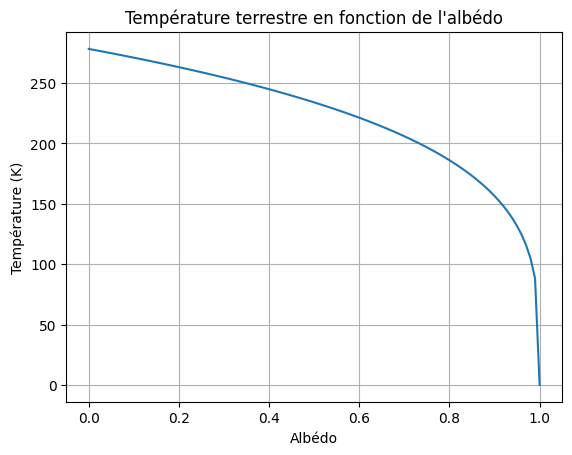

In [146]:
import matplotlib.pyplot as plt

#Tableau de valeurs d'albédo entre 0 et 1
albedo = np.linspace(0, 1, 100)

#Puissance absorbée par la Terre pour chaque valeur d'albédo
P_absorbee = P_terre * (1 - albedo)

#Température de la Terre pour chaque valeur d'albédo
T = (P_absorbee / (sigma * A_emission_terre))**(1/4)

# température en fonction de l'albédo
plt.plot(albedo, T)
plt.title("Température terrestre en fonction de l'albédo")
plt.xlabel("Albédo")
plt.ylabel("Température (K)")
plt.grid()
plt.show()

## Exercice 2


### 1) Constantes importantes

In [147]:
F_soleil = 1370 # Puissance reçue du soleil par m² au niveau de la terre (sans albedo)
G0 = 1 - 0.585 # Effet de serre: Niveau actuel
A0 = 0.33 # Albedo (nuages + glace des pôles)
boltzmann_k = 5.67*1e-8 # Constante de Boltzmann
tau_CO2 = 100 # Constante de temps por le retour à l'équilibre du CO2

En reprenant le cours, quelle est la puissance `F_in` reçue au niveau de la terre en fonction de `F_soleil` ?

In [148]:
# En reprenant le cours, on a, sans tenir compte de l'albédo : 
F_in = F_soleil / 4

print("En reprenant le cours, on a, sans tenir de l'albédo", F_in)

En reprenant le cours, on a, sans tenir de l'albédo 342.5


### 2) Albedo variable en fonction de la température

On vient préciser le fait que l'albédo peut être variable.  
L'albedo est influencée par la position des calottes de glace au niveau des terrestres. La position des calottes de glace dépend elle-même de la température sur terre: plus il fait chaud et plus la lattitude des calottes (appelé phi) se rapproche de 90 degré d'angle (pole nord ou sud) et inversement, plus il fait froid et plus phi se rapproche de 0 d'angle (équateur).  
La dépendance de l'albedo à phi est une fonction continue linéaire par morceaux.
Les fonctions sont données ci-dessous.

#### Relation entre la latitude (phi) des calottes glaciaires et la température de la terre (T)

In [149]:
# Coefficients pour les relations linéaires qui suivent
a = 1.45
b = 39.05

def phi_of_T(T): 
    # Latitude des calottes glaciaires en fonction de la température T
    return a*(T-273)+b

def T_of_phi(phi):
    # Température en fonction de la latitude des calottes glaciaires phi
    return (phi-b)/a + 273

#### Albedo

In [150]:
def albedo(phi = 65):
    # Albedo (entre 0 et 1) en fonction de la latitude des calottes glaciaires phi (en °)
    # - un albedo de 0 correspond au corps noir et 1 à un miroir parfait 
    # - phi est la latitude des calottes glacières. Varie entre 0 (équateur) et 90 (pole)
    # - on étend la fonction en dehors de [0,90] par continuité et avec des valeurs constantes
    if phi > 90:
        return 0.41 - 2.7 * 1e-3 * 60
    if phi < 0:
        return 0.9
    if phi > 30:
        return 0.41 - 2.7 * 1e-3 * (phi - 30)
    return 0.9 - 0.016 * phi

a) Afficher la courbe représentative de l'albedo en fonction de la température, variant entre 150 et 400 Kelvin. Pour la visualisation vous utiliserez des températures en **degrés celsius**. Il faudra bien préciser la conversion de Kelvin en Celsius.

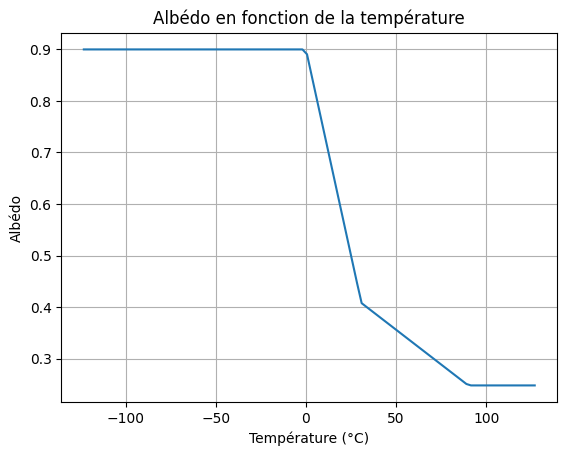

In [151]:
# tableau de températures entre 150 K et 400 K
T = np.linspace(150, 400, 100)

# conversion des températures de Kelvin en degrés Celsius
T_celsius = T - 273.15

# latitude des calottes glaciaires en fonction de la température
phi = T_celsius

# calcul de l'albédo pour chaque température
A = [albedo(p) for p in phi]

# albédo en fonction de la température
plt.plot(T_celsius, A)
plt.xlabel("Température (°C)")
plt.ylabel("Albédo")
plt.title("Albédo en fonction de la température")
plt.grid()
plt.show()

b) Quelles est la valeur minimale de l'albedo ? La valeur maximale ?  

In [152]:
#valeur minimale de l'albédo
A_min = min(A)

#valeur maximale de l'albédo
A_max = max(A)

print("La valeur minimale de l'albédo est", A_min)
print("La valeur maximale de l'albédo est", A_max)

La valeur minimale de l'albédo est 0.24799999999999997
La valeur maximale de l'albédo est 0.9


c) A partir de quelle(s) valeur(s) l'albedo devient constante ?

L'albédo semble devenir constante lorsque phi < 0 et lorsque phi > 90 

d) Interpréter ces résultats

Quand la température est faible, les calottes glaciaires descendent vers les basses latitudes, donc la Terre réfléchit davantage le rayonnement solaire : l'albédo est élevé. Quand la température augmente, les glaces se rapprochent des pôles, donc la surface réfléchissante diminue et l'albédo baisse. Plus il fait chaud, moins il y a de glace, plus la Terre absorbe d'énergie, donc elle peut se réchauffer encore davantage.

### 3) Températures d'équilibre

On redonne la fonction qui donne la température à l'équilibre de la terre connaissant l'albedo A et la fraction de gaz à effet de serre G.  
Il s'agit d'une température où la puissance reçue par le soleil est égale à la puissance rayonnée par la terre. En dehors d'une température d'équilibre il y a un déséquilibre dans les puissances reçues et émises.

In [153]:
def temperature_equilibre(A = 0, G= 0):
    # Température d'équilibre T (en K) issu du bilan radiatif simplifié avec la loi de Stefan Boltzmann:
    # (1-A)F_in = 4(1-G) sigma T^4
    # - A: albedo
    # - G: fraction gaz à effet de serre

    T = (F_in*(1-A)/ (4*boltzmann_k*(1-G) ))**(1/4)
    return T

a) A quoi correspond `G` dans le cours ? 

Dans le cours, G correspond à l’effet de serre. C’est la fraction du rayonnement infrarouge retenue par l’atmosphère. Si G augmente, la Terre perd moins d’énergie vers l’espace, donc la température d’équilibre augmente.

b) Afficher sur la même courbe 1) la puissance par $m^2$ reçue du soleil par la terre, en fonction de la température 2) la puissance rayonnée par la terre, en prenant en compte un effet de serre égal à G0

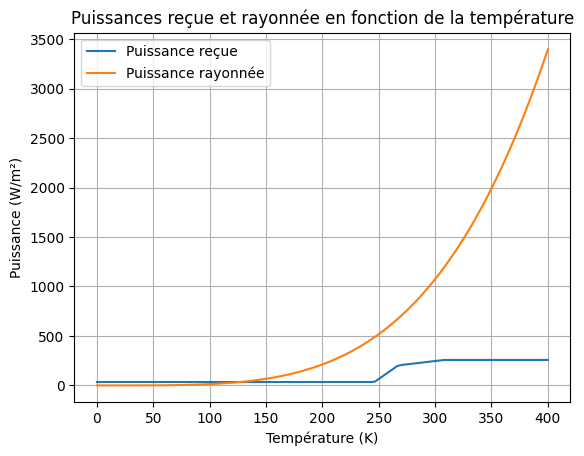

In [154]:
T = np.linspace(0, 400, 100)
phi = phi_of_T(T)
A = np.array([albedo(p) for p in phi])
#puissance reçue par la Terre par m²
P_recue = F_in * (1 - A)
#puissance rayonnée par la Terre avec effet de serre G0
P_rayonnée = 4 * boltzmann_k * (1 - G0) * T**4

plt.plot(T, P_recue, label="Puissance reçue")
plt.plot(T, P_rayonnée, label="Puissance rayonnée")
plt.xlabel("Température (K)")
plt.ylabel("Puissance (W/m²)")
plt.title("Puissances reçue et rayonnée en fonction de la température")
plt.legend()
plt.grid()
plt.show()

c) Combien de fois les courbes se croisent ? A quoi correspondent ces croisements ?

Les deux courbes se croisent une seule fois à 120 K. Ce croisement correspond à une température d'équilibre du système. À cette température, la puissance reçue du Soleil est égale à la puissance rayonnée par la Terre. Le bilan énergétique est donc nul et la température reste constante.

d) On utilise une recherche de changement de signe, pour trouver un moyen simple d'identifier ces points de croisement, comme des températures d'annulation de la différence entre les valeurs de la puissance émise et de la puissance reçue.  
Plus généralement étant donné des valeurs positives ou négatives dans un tableau `T`, on veut les indices `i` tels que `T[i]*T[i+1]<0`. Vous pouvez utiliser des boucles et si vous utilisez `numpy` vous aurez besoin de la fonction `numpy.where`.

In [156]:
difference = P_rayonnée - P_recue
indices = np.where(difference[:-1] * difference[1:] < 0)[0]

for i in indices:
    print("Croisement entre", T[i], "K et", T[i+1], "K")

Croisement entre 125.25252525252526 K et 129.2929292929293 K


e) (**bonus**) Faire varier G et regarder comment les points de croisement évoluent avec G. Vous ferez un graphique avec G en absisse et les températures de croisement en ordonnées

### 4) Simulations

Dans SimClimat https://web.lmd.jussieu.fr/~crlmd/simclimat/ est implémenté un modèle pour l'évolution de la température qui se décompose en

- une étape initiale où on part d'une température $T_0$. 
- des mises à jour successives de la température $T_{n+1}$ à partir de la température $T_n$ et de la température à l'équilibre $T_{eq}$ qui dépend aussi de $T_n$ via l'albedo. Les deux températures $T_n$ et $T_{n+1}$ correspondent à deux instants séparés d'un pas de temps $dt$ (qu'on prend ici égal à 0.25 années).
    
On prend aussi:
	 
- $F_{in}$ : la valeur trouvée à la question 1 de cet exercice.
	
- $A(T)$: l'albedo en fonction de la température. C'est une fonction continue, linéaire par morceaux 
	 
- G = fraction de rayonnement infra-rouge émis par la terre retenu par effet de serre
	 G = G0 + GCO2 (on n'ajoute pas GH2O pour le moment)
	
- s = constante de Boltzmann 5.67 10^-8 Wm^2K^-4

In [157]:
def simClimat_simplifie(T0, N, dt = 0.25, G=G0):
    # Evolution de la température au cours du temps à partir des paramètres suivants
    # - T0: temperature initiale (en K)
    # - N: nombre de pas de temps considérés pour la simulation
    # - dt: pas de temps, en années. Par défaut on prend 3 mois = 1/4 d'années
    # - G: fraction de gaz à effet de serre présent dans l'atmosphère. G = G0 = 0.415 par défaut
    #
    # On retourne la liste des temperatures (en K) calculé au cours de l'évolution
    temperatures = [T0] 
    T = T0
    for i in range(N):
        # 1. Calcul de l'Albedo compte tenu de T
        phi = phi_of_T(T) 
        A = albedo(phi)
        
        # 2. Température à l'équilibre
        T_eq = ((1-A)*F_in/(4*(1-G)*boltzmann_k))**(1/4)
        
        # 3. Mise à jour de la température
        T = T + (T_eq -T)*dt/tau_CO2 # (1-np.exp(-dt/tau)) se simplifie à dt petit
        
        # 4. On enregistre la valeur 
        temperatures.append(T)
    return temperatures

a) Simuler l'évolution de la température, en partant d'une température initiale correspondant à l'équilibre le plus chaud obtenu pour G0. Vous prendrez N = 10000.  

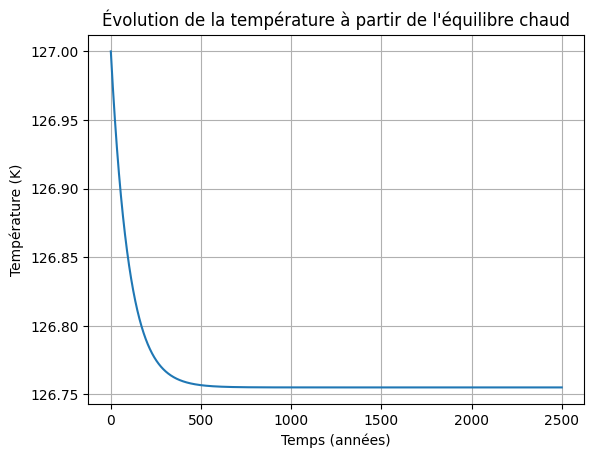

In [158]:
#Température initiale correspondant à l'équilibre le plus chaud
T0 = 127

#Nombre de pas de temps
N = 10000

#Simulation de l'évolution de la température
temperatures = simClimat_simplifie(T0, N)

#Temps associé à chaque température
temps = np.arange(N + 1) * 0.25

#Tracer l'évolution de la température
plt.plot(temps, temperatures)
plt.xlabel("Temps (années)")
plt.ylabel("Température (K)")
plt.title("Évolution de la température à partir de l'équilibre chaud")
plt.grid()
plt.show()

b) A combien d'années cela correspond il ?

In [159]:
#Nombre de pas de temps
N = 10000
#Pas de temps en années
dt = 0.25
#Durée totale
duree = N * dt

print("La simulation correspond à", duree, "années")

La simulation correspond à 2500.0 années


c) Quelle est l'évolution de la température ? Est ce étonnant ?

In [160]:
#nouvelle valeur de l'effet de serre
G_nouveau = 0.43
#simulation avec G = 0.43
temperatures_G43 = simClimat_simplifie(T0, N, G=G_nouveau)
#variation de température entre le début et la fin
variation_T = temperatures_G43[-1] - temperatures_G43[0]

print("La variation de température est", variation_T, "K")
print("La variation de température est aussi", variation_T, "°C")

La variation de température est 0.5809017609248173 K
La variation de température est aussi 0.5809017609248173 °C


La température évolue très peu, elle reste proche de sa valeur initiale. Ce n’est pas étonnant, car on part d’une température correspondant à un équilibre. À l’équilibre, la puissance reçue par la Terre est égale à la puissance rayonnée.

d) On part toujours de la température précédente mais on suppose que la fraction d'effet de serre est passée à 0.43. Quelle est la variation de température associée ?   
Comparez avec les informations que vous connaissez ou que vous pourrez trouver sur la hausse de température liée aux émissions de gaz à effet de serre.

In [161]:
#nouvelle valeur de l'effet de serre
G = 0.43
#simulation
temperatures_G43 = simClimat_simplifie(T0, N, G=G)
#variation de température
delta_T = temperatures_G43[-1] - temperatures_G43[0]

print("Variation de température :", delta_T, "K")

Variation de température : 0.5809017609248173 K


Quand G passe à 0,43, la température augmente de 0.58 K. Ce résultat est cohérent avec l’idée que l’augmentation des gaz à effet de serre réchauffe la Terre, car ils retiennent davantage de rayonnement infrarouge. D'après le rapport de l'IPCC : https://www.ipcc.ch/report/ar6/syr/resources/spm-headline-statements/?utm_source=chatgpt.com , "Les activités humaines, principalement à travers les émissions de gaz à effet de serre, ont incontestablement causé le réchauffement climatique, la température de surface mondiale ayant atteint 1,1 °C.". Cette différence pour s'expliquer par la simplicité du modèle que l'on utilisé qui ne prend pas en compte certains paramêtres rééls comme on a pu le voir plus haut. Cependant on peut voir qu'une augmentation de l'effet de serre conduit à une augmentation de la température d'équilibre de la Terre dans les deux cas. 